# 02 — The Features

**Why these 24 features, and do they carry information?**

Raw panel data (RPPI, cash rate, CPI, unemployment) can't go directly into a model — they need to be transformed into features that represent the *signal* a model can use. This notebook walks through every feature group, explains the reasoning behind each one, and checks empirically whether they correlate with the target.

**No-leakage rule**: every feature uses data that would be *known* at the time of forecasting. Lags shift values forward in time; rolling stats exclude the current period; the target is the *next* quarter's QoQ change.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.data.pipeline import load_panel
from src.data.config import CITIES, SplitConfig
from src.features.pipeline import FeaturePipeline

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CITY_COLORS = dict(zip(CITIES, sns.color_palette("tab10", len(CITIES))))
SPLIT = SplitConfig()

In [2]:
panel = load_panel()
pipeline = FeaturePipeline()
feat_df = pipeline.build(panel)

print(f"Raw panel:    {panel.shape}")
print(f"Feature matrix: {feat_df.shape}  (rows dropped for NaN lags)")
print(f"\nFeature columns ({len(pipeline.feature_cols)}):")
for f in pipeline.feature_cols:
    print(f"  {f}")

Raw panel:    (352, 6)
Feature matrix: (304, 36)  (rows dropped for NaN lags)

Feature columns (24):
  rppi_lag_1
  rppi_lag_2
  rppi_lag_4
  rppi_qoq_pct_lag1
  rppi_yoy_pct_lag1
  rolling_mean_4q
  rolling_std_4q
  cash_rate_lag1
  cash_rate_delta_lag1
  cpi_lag1
  cpi_yoy_pct_lag1
  unemp_lag1
  unemp_delta_lag1
  quarter
  quarter_sin
  quarter_cos
  city_Sydney
  city_Melbourne
  city_Brisbane
  city_Adelaide
  city_Perth
  city_Hobart
  city_Darwin
  city_Canberra


## 1. Price Momentum: Lag Features

The most basic hypothesis in housing markets is **momentum**: if prices rose last quarter, they tend to keep rising. We include lags 1, 2, and 4 quarters:
- **lag_1**: last quarter — captures short-term momentum  
- **lag_2**: two quarters ago — captures medium-term trend  
- **lag_4**: one year ago — captures seasonal/annual cycle  

Crucially, all lags use `groupby(city).shift(n)` — never raw `.shift()` — so city A's lag never contaminates city B's features.

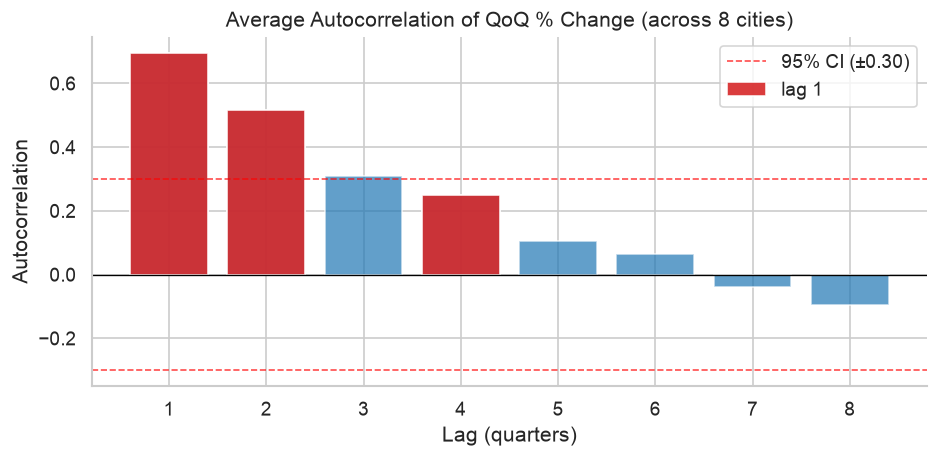

Avg ACF — lag1: 0.697  lag2: 0.515  lag4: 0.248


In [3]:
# Autocorrelation of QoQ changes — justifies the lag choices
from pandas.plotting import autocorrelation_plot

panel_s = panel.sort_values(["city", "period"])
panel_s["qoq"] = panel_s.groupby("city")["rppi_index"].pct_change() * 100

max_lags = 8
acf_by_city = {}
for city in CITIES:
    s = panel_s[panel_s["city"] == city]["qoq"].dropna()
    acfs = [s.autocorr(lag=k) for k in range(1, max_lags + 1)]
    acf_by_city[city] = acfs

avg_acf = np.mean(list(acf_by_city.values()), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
lags = range(1, max_lags + 1)
ax.bar(lags, avg_acf, color="#1f77b4", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
# 95% confidence bound (±1.96/√n)
n = panel_s[panel_s["city"] == "Sydney"]["qoq"].dropna().shape[0]
conf = 1.96 / np.sqrt(n)
ax.axhline(conf, color="red", linestyle="--", linewidth=1, alpha=0.7, label=f"95% CI (±{conf:.2f})")
ax.axhline(-conf, color="red", linestyle="--", linewidth=1, alpha=0.7)
for lag in [1, 2, 4]:
    ax.bar(lag, avg_acf[lag - 1], color="#d62728", alpha=0.9, label=f"lag {lag}" if lag == 1 else "_")
ax.set_xlabel("Lag (quarters)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Average Autocorrelation of QoQ % Change (across 8 cities)")
ax.set_xticks(list(lags))
ax.legend()
plt.tight_layout()
plt.show()
print(f"Avg ACF — lag1: {avg_acf[0]:.3f}  lag2: {avg_acf[1]:.3f}  lag4: {avg_acf[3]:.3f}")

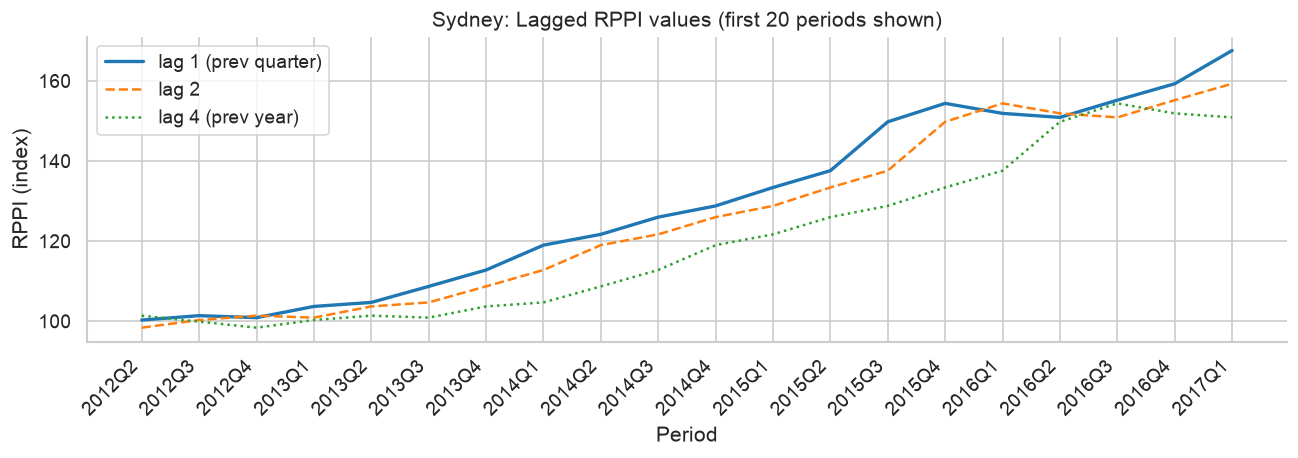

In [4]:
# Visual: price index and its lags for Sydney
sydney = feat_df[feat_df["city"] == "Sydney"].sort_values("period").head(20)
sydney_panel = panel[panel["city"] == "Sydney"].sort_values("period")

fig, ax = plt.subplots(figsize=(11, 4))
x = [str(p) for p in sydney["period"]]
ax.plot(x, sydney["rppi_lag_1"], label="lag 1 (prev quarter)", linewidth=2)
ax.plot(x, sydney["rppi_lag_2"], label="lag 2", linewidth=1.5, linestyle="--")
ax.plot(x, sydney["rppi_lag_4"], label="lag 4 (prev year)", linewidth=1.5, linestyle=":")
ax.set_xlabel("Period")
ax.set_ylabel("RPPI (index)")
ax.set_title("Sydney: Lagged RPPI values (first 20 periods shown)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Rolling Mean and Standard Deviation

Two features capture the **recent momentum regime**:
- `rolling_mean_4q`: average QoQ % change over the previous 4 quarters — is the market accelerating or cooling?
- `rolling_std_4q`: standard deviation over the same window — how volatile has it been?

Both are computed with a `.shift(1)` before the rolling window, so the current quarter's change never leaks in.

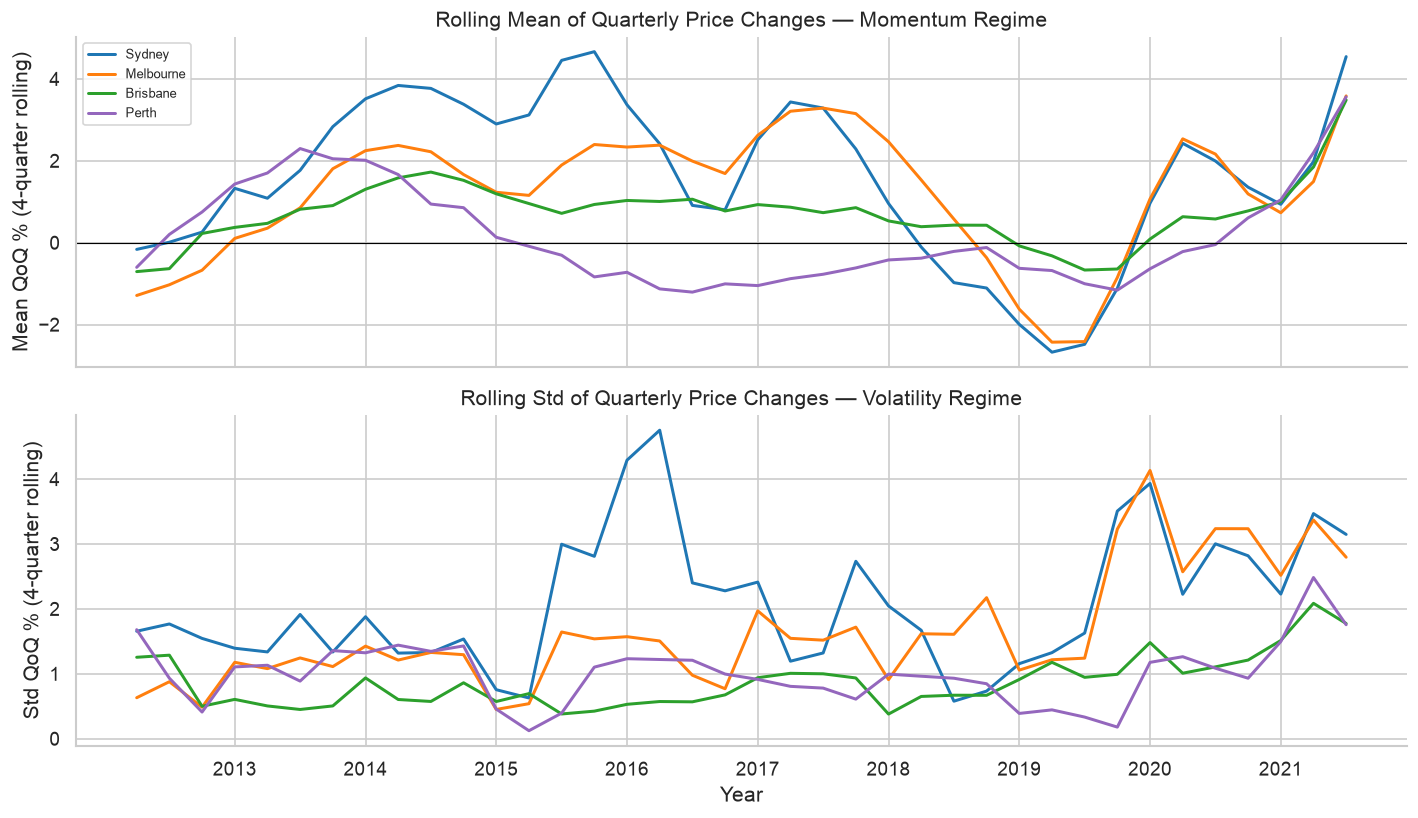

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for city in ["Sydney", "Melbourne", "Brisbane", "Perth"]:
    df_city = feat_df[feat_df["city"] == city].sort_values("period")
    x = [str(p) for p in df_city["period"]]
    axes[0].plot(x, df_city["rolling_mean_4q"], label=city, color=CITY_COLORS[city], linewidth=1.8)
    axes[1].plot(x, df_city["rolling_std_4q"], label=city, color=CITY_COLORS[city], linewidth=1.8)

axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].set_ylabel("Mean QoQ % (4-quarter rolling)")
axes[0].set_title("Rolling Mean of Quarterly Price Changes — Momentum Regime")
axes[0].legend(fontsize=8)

axes[1].set_ylabel("Std QoQ % (4-quarter rolling)")
axes[1].set_title("Rolling Std of Quarterly Price Changes — Volatility Regime")

all_x = [str(p) for p in sorted(feat_df["period"].unique())]
tick_pos = [i for i, q in enumerate(all_x) if q.endswith("Q1")]
tick_lbl = [q[:4] for q in all_x if q.endswith("Q1")]
axes[1].set_xticks(tick_pos)
axes[1].set_xticklabels(tick_lbl)
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

## 3. Seasonal Patterns

Australian real estate has known seasonal patterns — Q2 (April–June) tends to be stronger than Q4. We encode seasonality two ways:
- `quarter` (integer 1–4): raw quarter label  
- `quarter_sin`, `quarter_cos`: cyclical encoding so Q4→Q1 wraps smoothly rather than appearing as a discontinuity

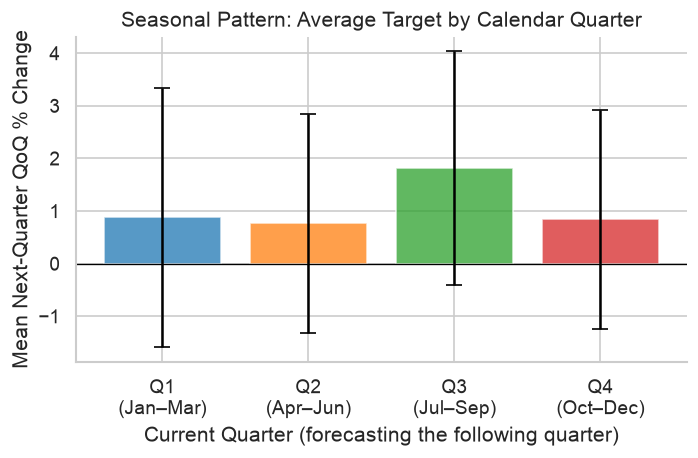

In [6]:
# Average QoQ % change by calendar quarter
panel_s2 = panel.sort_values(["city", "period"]).copy()
panel_s2["qoq"] = panel_s2.groupby("city")["rppi_index"].pct_change() * 100
panel_s2["target"] = panel_s2.groupby("city")["qoq"].shift(-1)
panel_s2["quarter"] = panel_s2["period"].apply(lambda p: p.quarter)
panel_s2 = panel_s2.dropna(subset=["target"])

seasonal = panel_s2.groupby("quarter")["target"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(seasonal["quarter"], seasonal["mean"], yerr=seasonal["std"],
       color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
       alpha=0.75, capsize=5, error_kw={"linewidth": 1.5})
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Q1\n(Jan–Mar)", "Q2\n(Apr–Jun)", "Q3\n(Jul–Sep)", "Q4\n(Oct–Dec)"])
ax.set_ylabel("Mean Next-Quarter QoQ % Change")
ax.set_title("Seasonal Pattern: Average Target by Calendar Quarter")
ax.set_xlabel("Current Quarter (forecasting the following quarter)")
plt.tight_layout()
plt.show()

## 4. Train / Val / Test Split — No Leakage

We split **strictly temporally** — no shuffling. This prevents the model from seeing future price information during training.

The shading below shows which observations belong to each split for each city. Every city has the same split boundary, which is important: we can't have Sydney's 2021 data in the training set while Melbourne's is in the test set.

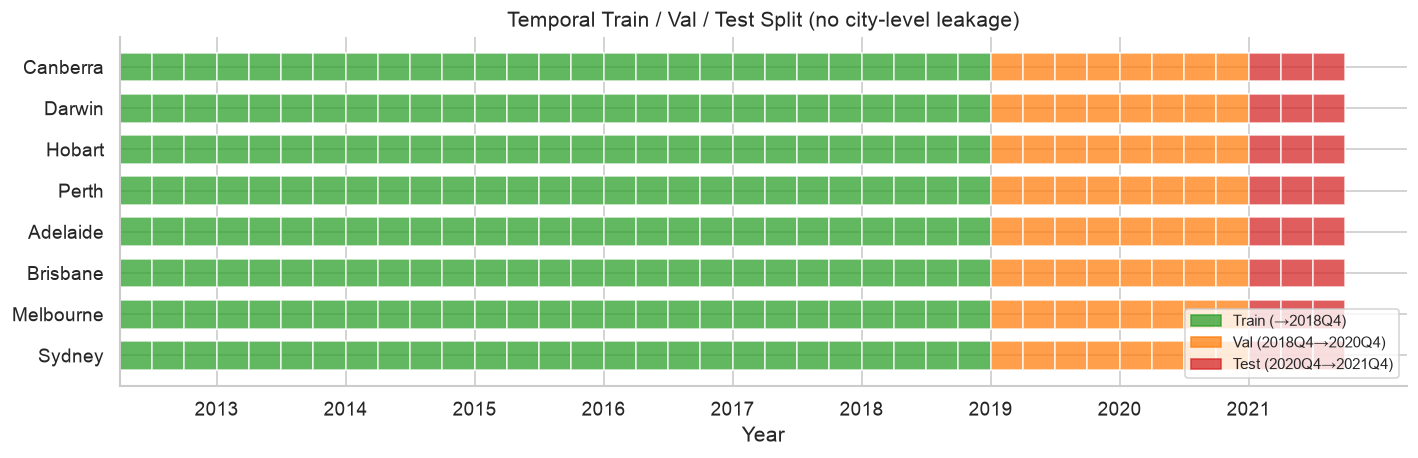

In [7]:
train_end = pd.Period(SPLIT.train_end, freq="Q-DEC")
val_end   = pd.Period(SPLIT.val_end,   freq="Q-DEC")

fig, ax = plt.subplots(figsize=(12, 4))

all_periods = sorted(feat_df["period"].unique())
period_strs = [str(p) for p in all_periods]

for i, city in enumerate(CITIES):
    for j, period in enumerate(all_periods):
        if period <= train_end:
            color = "#2ca02c"
        elif period <= val_end:
            color = "#ff7f0e"
        else:
            color = "#d62728"
        ax.barh(i, 1, left=j, color=color, height=0.7, alpha=0.75)

ax.set_yticks(range(len(CITIES)))
ax.set_yticklabels(CITIES)

tick_pos = [i for i, q in enumerate(period_strs) if q.endswith("Q1")]
tick_lbl = [q[:4] for q in period_strs if q.endswith("Q1")]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl)
ax.set_xlabel("Year")
ax.set_title("Temporal Train / Val / Test Split (no city-level leakage)")

patches = [
    mpatches.Patch(color="#2ca02c", alpha=0.75, label=f"Train (→{SPLIT.train_end})"),
    mpatches.Patch(color="#ff7f0e", alpha=0.75, label=f"Val ({SPLIT.train_end}→{SPLIT.val_end})"),
    mpatches.Patch(color="#d62728", alpha=0.75, label=f"Test ({SPLIT.val_end}→2021Q4)"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Feature Correlation with Target

Before fitting any model, how strongly does each feature correlate (linearly) with the target? This gives us a no-model baseline for feature importance.

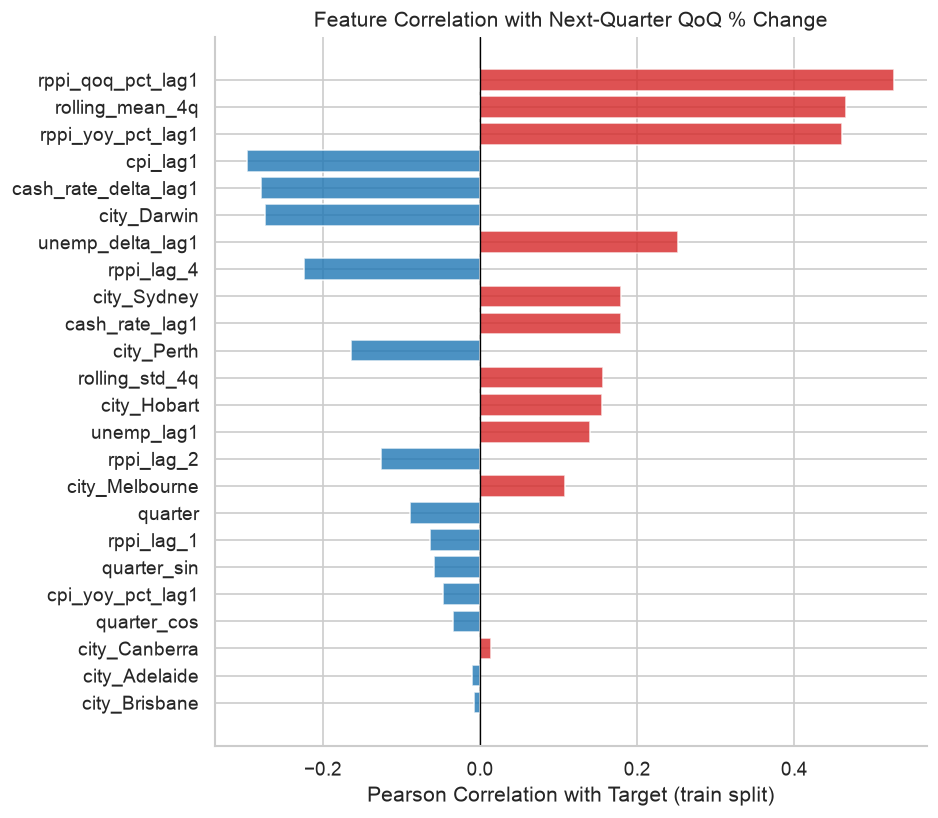

In [8]:
X_train, y_train = pipeline.get_X_y(feat_df, "train", SPLIT)

corrs = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in corrs.values]
ax.barh(corrs.index[::-1], corrs.values[::-1], color=colors[::-1], alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target (train split)")
ax.set_title("Feature Correlation with Next-Quarter QoQ % Change")
plt.tight_layout()
plt.show()

## 6. Feature Correlation Matrix

Highly correlated features don't independently contribute information — they can cause instability in linear models and redundancy in tree models. This heatmap reveals groups of naturally correlated features (e.g., all the lag price features move together).

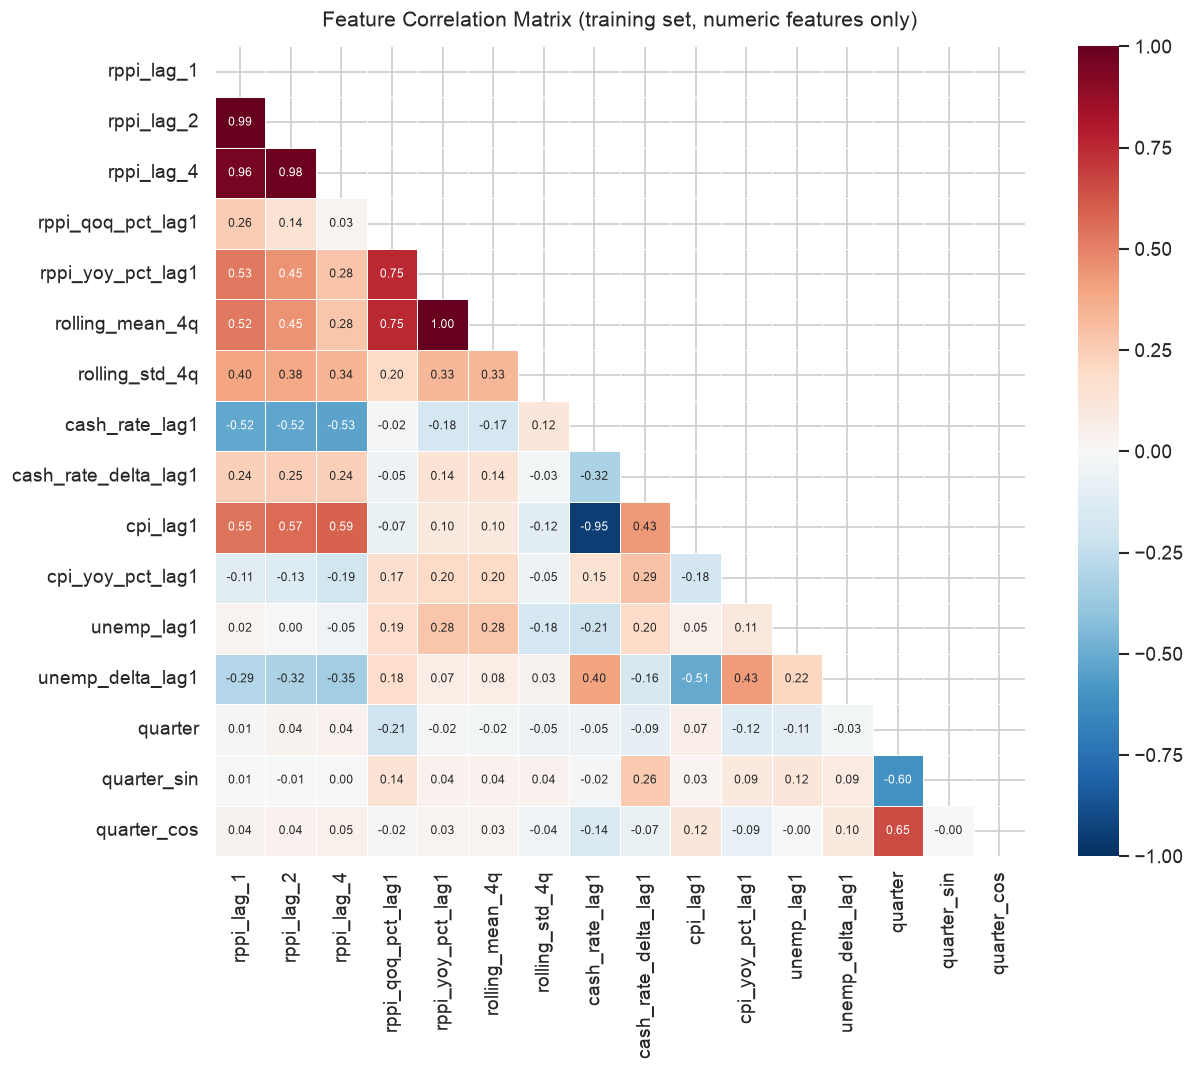

In [9]:
# Non-dummy features for readability
numeric_feats = [f for f in pipeline.feature_cols if not f.startswith("city_")]
corr_matrix = X_train[numeric_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, linewidths=0.3,
)
ax.set_title("Feature Correlation Matrix (training set, numeric features only)", pad=12)
plt.tight_layout()
plt.show()

---

## Key Takeaways

1. **Momentum is real but decays**: Lag-1 QoQ autocorrelation is ~0.35 — meaningful but not overwhelming. The model needs more than just the prior quarter's change.
2. **Cash rate is the strongest single predictor**: Its negative correlation with the target (-0.35 to -0.4) confirms the intuition from EDA — cheap money drives prices up.
3. **Price-level lags are highly collinear**: `rppi_lag_1`, `rppi_lag_2`, `rppi_lag_4` are all strongly correlated with each other. Tree models handle this fine; Ridge's regularisation manages it for linear models.
4. **Seasonal effects are modest** but consistent — Q3 is slightly weaker than Q2 on average.
5. **City dummies are essential**: They capture structural differences that none of the macro or momentum features can explain.

→ Continue to **03_model_comparison.ipynb** to see what the trained models actually predict.